In [1]:
import Pkg
Pkg.activate("../chebcoefs")
Pkg.instantiate()

  Activating project at `~/repos/WaveGreen2D/chebcoefs`


In [2]:
using CairoMakie
using FastChebInterp
using JLD2
using QuadGK
using StaticArrays
using WaveGreen2D.Chebyshev

In [3]:
# Tolerance is set by default to machine precision, but can be adjusted to the desired value.
# For a well chosen quadrature order, the maximum number of function evaluations does not go beyond 10³.
# For L₁ and L₂, especially close to the poles, the best quadrature order is between 24 and 34.
tol = eps()
imax = 1e3
qorder = 26


function mod_quadgk(f, a, b; rtol=sqrt(eps()), atol=0, maxevals=10^7, order=7)
    # Put 26 as the first try.
    qorder_vals = [[26, 25, 24]; collect(27:34)]
    
    if !(order in qorder_vals)
        pushfirst!(qorder_vals, order)
    end

    ∫f = err = nothing
    
    for qo in qorder_vals
        ∫f, err, count = quadgk_count(f, a, b; rtol=rtol, atol=atol, maxevals=maxevals, order=qo)
        if count < maxevals
            return ∫f, err
        end
    end

    @warn "Reached the maximum number of function evaluations" #maxlog=1
    
    return ∫f, err
end


function L₁H(x::AbstractVector{<:Real})
    A, B, H = x
    
    f(u) = (u + H) / (u - H - (u + H)*exp(-2u))
    g(u) = exp(-u*(2+B)) + exp(-u*(2-B))
    h(u) = cos(u*A)
    p(u) = (f(u) * g(u) * h(u) + exp(-u)) / u
    
    path = (0.0, H+im, H+1.0, Inf)
    
    y  = mod_quadgk(p, path[1], path[2]; rtol=tol, atol=tol, maxevals=imax, order=qorder)[1]
    y += mod_quadgk(p, path[2], path[3]; rtol=tol, atol=tol, maxevals=imax, order=qorder)[1]
    y += mod_quadgk(p, path[3], path[4]; rtol=tol, atol=tol, maxevals=imax)[1]
    
    return real(y)
end


function L₂H(x::AbstractVector{<:Real})
    A, B, H = x

    f(u) = (u + H) / (u - H - (u + H)*exp(-2u))
    g(u) = (u + H)^2 / ((u - H)^2 - (u^2 - H^2)*exp(-2u))
    p(u) = exp(-u*(2+B))
    q(u) = exp(-u*(4-B))
    r(u) = cos(u*A)
    
    h(u) = (f(u)*p(u) + g(u)*q(u)) * r(u) / u
    
    path = (0.0, H+im, H+1.0, Inf)
    
    y  = mod_quadgk(h, path[1], path[2]; rtol=tol, atol=tol, maxevals=imax, order=qorder)[1]
    y += mod_quadgk(h, path[2], path[3]; rtol=tol, atol=tol, maxevals=imax, order=qorder)[1]
    y += mod_quadgk(h, path[3], path[4]; rtol=tol, atol=tol, maxevals=imax)[1]
    
    return real(y)
end


function L₁C(x::AbstractVector{<:Real})
    A, B, C = x  # C = ln(H)
    x̄ = [A, B, exp(C)]
    return L₁H(x̄)
end


function L₂C(x::AbstractVector{<:Real})
    A, B, C = x  # C = ln(H)
    x̄ = [A, B, exp(C)]
    return L₂H(x̄)
end


function generate_coefficients(L, n, lb, ub; tol=eps())
    x = chebpoints(n, lb, ub)
    c = chebinterp(L.(x), lb, ub; tol=tol)
    return c.coefs
end;

In [4]:
# The domains of L₁(A, B, C) and L₂(A, B, C) are split in three parts along the dimension C, where C = log₁₀H.
# The split was adjusted to make the number of coefficients in each domain approximately the same.

# Functions used in each domain
L₁_funcs = [L₁H, L₁C, L₁C]
L₂_funcs = [L₂C, L₂C, L₂C, L₂C]

# Domains lower and upper bounds
L₁_Hvals = [1e-2, 1.64, π, 7.0]
L₂_Hvals = [1e-2, 0.4, 1.5, π, 7.0]

L₁_lb = [
    SA[0.0, 0.0, L₁_Hvals[1]],
    SA[0.0, 0.0, log(L₁_Hvals[2])],
    SA[0.0, 0.0, log(L₁_Hvals[3])],
]

L₁_ub = [
    SA[0.5, 1.0, L₁_Hvals[2]],
    SA[0.5, 1.0, log(L₁_Hvals[3])],
    SA[0.5, 1.0, log(L₁_Hvals[4])],
]

L₂_lb = [
    SA[0.0, 0.0, log(L₂_Hvals[1])],
    SA[0.0, 0.0, log(L₂_Hvals[2])],
    SA[0.0, 0.0, log(L₂_Hvals[3])],
    SA[0.0, 0.0, log(L₂_Hvals[4])],
]

L₂_ub = [
    SA[0.5, 2.0, log(L₂_Hvals[2])],
    SA[0.5, 2.0, log(L₂_Hvals[3])],
    SA[0.5, 2.0, log(L₂_Hvals[4])],
    SA[0.5, 2.0, log(L₂_Hvals[5])],
]

# Polynomial order
L₁_n = [
    (14, 19, 19),
    (14, 19, 19),
    (14, 19, 20),
]

L₂_n = [
    (11, 18, 23),
    (11, 18, 22),
    (12, 20, 21),
    (13, 21, 21),
];

In [5]:
L₁_series = Array{ChebyshevSeries{Float64, 3}}(undef, 3)
L₂_series = Array{ChebyshevSeries{Float64, 3}}(undef, 4)

for i in 1:3
    coefs₁ = generate_coefficients(L₁_funcs[i], L₁_n[i], L₁_lb[i], L₁_ub[i]; tol=tol)
    coefs₂ = generate_coefficients(L₂_funcs[i], L₂_n[i], L₂_lb[i], L₂_ub[i]; tol=tol)

    L₁_series[i] = ChebyshevSeries(coefs₁, L₁_lb[i], L₁_ub[i])
    L₂_series[i] = ChebyshevSeries(coefs₂, L₂_lb[i], L₂_ub[i])
end

i = 4
coefs₂ = generate_coefficients(L₂_funcs[i], L₂_n[i], L₂_lb[i], L₂_ub[i]; tol=tol)
L₂_series[i] = ChebyshevSeries(coefs₂, L₂_lb[i], L₂_ub[i])

@save "chebseries.jld2" L₁_series L₂_series

# L₁_cluster = ChebyshevCluster(L₁_series...)
# L₂_cluster = ChebyshevCluster(L₂_series...)

# jldsave("chebclusters.jld2"; L₁=L₁_cluster, L₂=L₂_cluster)

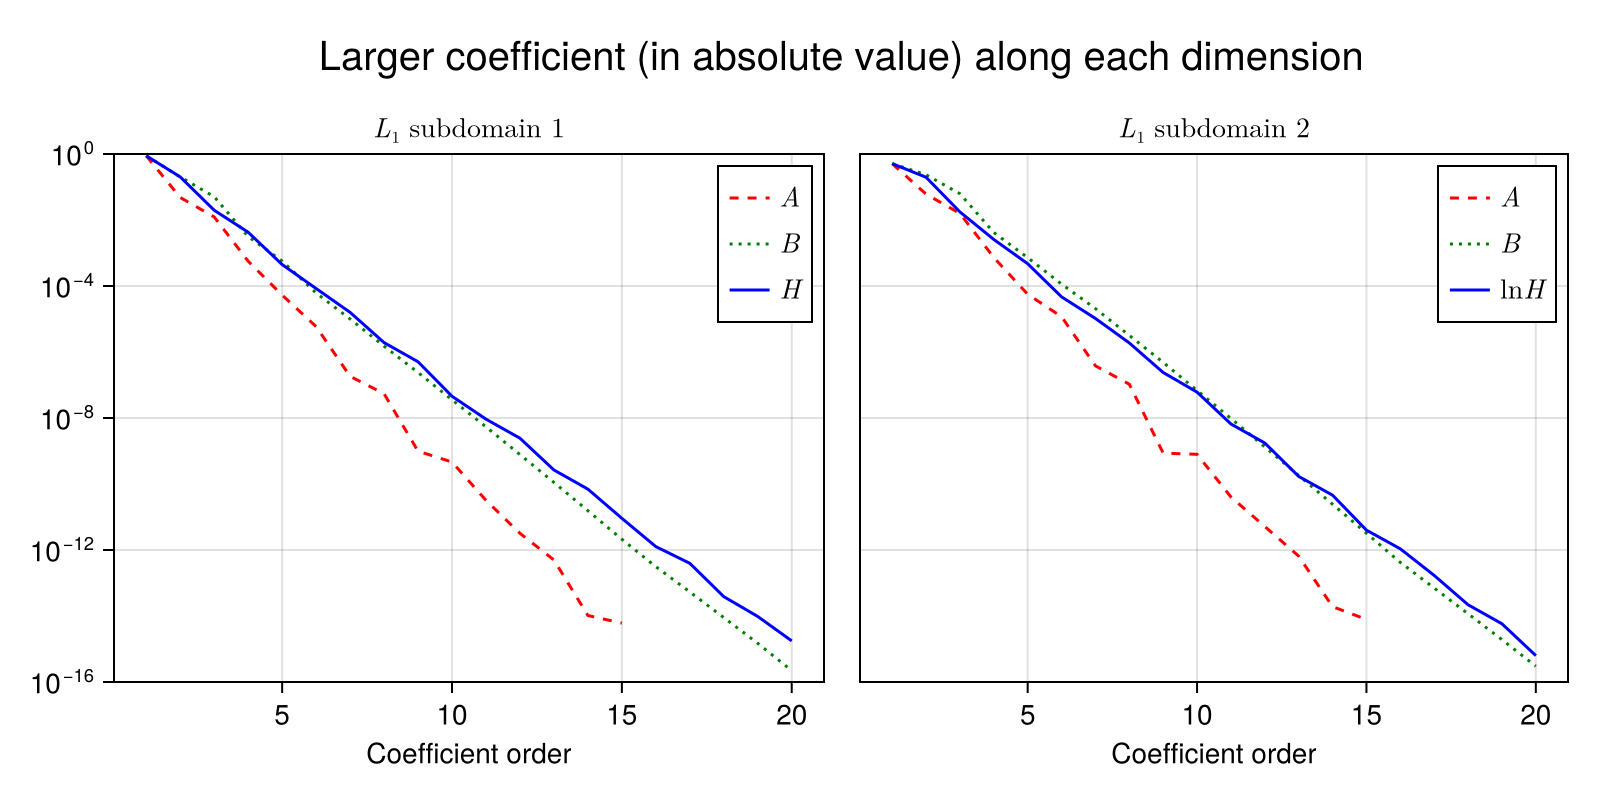

In [13]:
L_series = L₁_series
Lname = "L_{1}"
filename = "l1_maxcoefs.svg"
ndomains = length(L_series) - 1

fig = Figure(size=(400*ndomains, 400))

axes = [Axis(
        fig[1, m],
        yscale=log10,
        title=L"%$Lname \text{ subdomain } %$m",
        xlabel="Coefficient order",
        yticks=LogTicks(LinearTicks(5)),
        limits=(nothing, (1e-16, 1.0)),
    ) for m in 1:ndomains
]

for m in 2:ndomains
    axes[m].yticklabelsvisible = false
    axes[m].yticksvisible = false
end

supertitle = Label(fig[0, :], "Larger coefficient (in absolute value) along each dimension", fontsize = 20)

for m in 1:ndomains
    coefs = L_series[m].coefs
    
    coefs_A = [maximum(abs.(coefs[i, :, :])) for i in 1:size(coefs, 1)]
    coefs_B = [maximum(abs.(coefs[:, j, :])) for j in 1:size(coefs, 2)]
    coefs_log₁₀H = [maximum(abs.(coefs[:, :, k])) for k in 1:size(coefs, 3)]
    
    lines!(axes[m], 1:size(coefs, 1), coefs_A, color=:red, linestyle=:dash, label=L"A")
    lines!(axes[m], 1:size(coefs, 2), coefs_B, color=:green, linestyle=:dot, label=L"B")
    
    if m == 1
        lines!(axes[m], 1:size(coefs, 3), coefs_log₁₀H, color=:blue, linestyle=:solid, label=L"H")
    else
        lines!(axes[m], 1:size(coefs, 3), coefs_log₁₀H, color=:blue, linestyle=:solid, label=L"\ln H")
    end

    axislegend(axes[m])
end

save(filename, fig)
fig

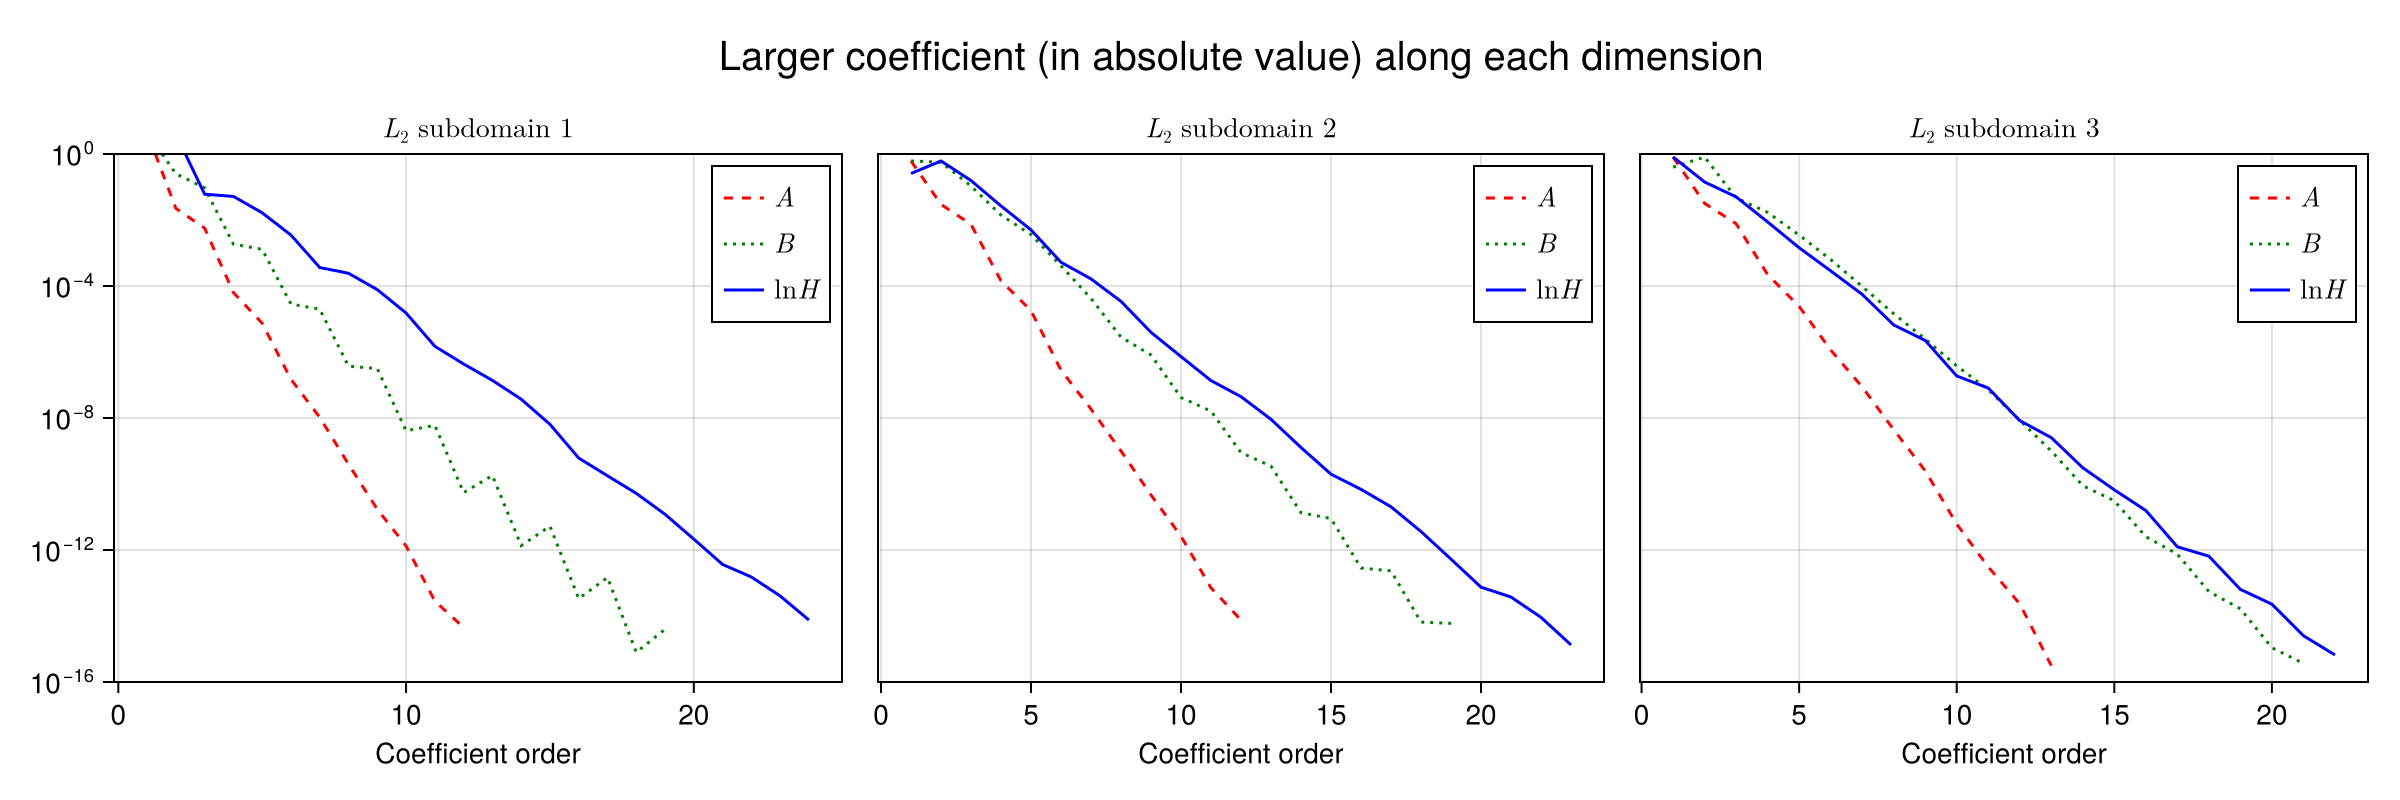

In [14]:
L_series = L₂_series
Lname = "L_{2}"
filename = "l2_maxcoefs.svg"
ndomains = length(L_series) - 1

fig = Figure(size=(400*ndomains, 400))

axes = [Axis(
        fig[1, m],
        yscale=log10,
        title=L"%$Lname \text{ subdomain } %$m",
        xlabel="Coefficient order",
        yticks=LogTicks(LinearTicks(5)),
        limits=(nothing, (1e-16, 1.0)),
    ) for m in 1:ndomains
]

for m in 2:ndomains
    axes[m].yticklabelsvisible = false
    axes[m].yticksvisible = false
end

supertitle = Label(fig[0, :], "Larger coefficient (in absolute value) along each dimension", fontsize = 20)

for m in 1:ndomains
    coefs = L_series[m].coefs
    
    coefs_A = [maximum(abs.(coefs[i, :, :])) for i in 1:size(coefs, 1)]
    coefs_B = [maximum(abs.(coefs[:, j, :])) for j in 1:size(coefs, 2)]
    coefs_log₁₀H = [maximum(abs.(coefs[:, :, k])) for k in 1:size(coefs, 3)]
    
    lines!(axes[m], 1:size(coefs, 1), coefs_A, color=:red, linestyle=:dash, label=L"A")
    lines!(axes[m], 1:size(coefs, 2), coefs_B, color=:green, linestyle=:dot, label=L"B")
    lines!(axes[m], 1:size(coefs, 3), coefs_log₁₀H, color=:blue, linestyle=:solid, label=L"\ln H")

    axislegend(axes[m])
end

save(filename, fig)
fig